# Group 2 Final Project: SMS Spam Filter Model Comparison
Group 2: Cathy Lee, Evan Gray, Aviral Gusain

## Problem description

We will be creating models to solve the problem of spam messages. With a “spam messages” referring
to messages that are fraudulent or deceitful. Our models will decide if the given text is a spam or
ham message (classification) and can be used to filter out unwanted messages.


## Dataset

We will be using the dataset spam.tsv, which contains 5572 emails, 747 of which are spam and
4825 of which are ham. This database is sourced from kaggle.com, a webpage for machine
learning. This dataset was chosen due to its use in our selected research paper. The data is
formatted to have two fields, the label (spam/ham) and the message itself. The messages are
formatted as short text messages and try to represent real world messaging. The dataset itself can be found here https://www.kaggle.com/datasets/abdullahsaida011/smsspam

## Part 1: Exploratory Data Analysis (EDA)

* #### Load dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import nltk

df = pd.read_csv("spam.tsv", sep="\t")
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


* #### Report summart statistics

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types and non-null counts:")
print(df.info())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (percent):")
print(df["label"].value_counts(normalize=True) * 100)

print("\nSummary statistics for numerical columns:")
print(df[["length", "punct"]].describe())

print("\nAverage values by class:")
print(df.groupby("label")[["length", "punct"]].mean())

Shape of dataset: (5572, 4)

Column names:
Index(['label', 'message', 'length', 'punct'], dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   length   5572 non-null   int64 
 3   punct    5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB
None

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class distribution (percent):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

Summary statistics for numerical columns:
            length        punct
count  5572.000000  5572.000000
mean     80.489950     4.177495
std      59.942907     4.623919
min       2.000000     0.000000
25%      36.000000     2.000000
50%      62.000000     3.000000
75%     122.000000     6

* #### Visualize feature distributions & general visualisations (3 or more) (with labels!)

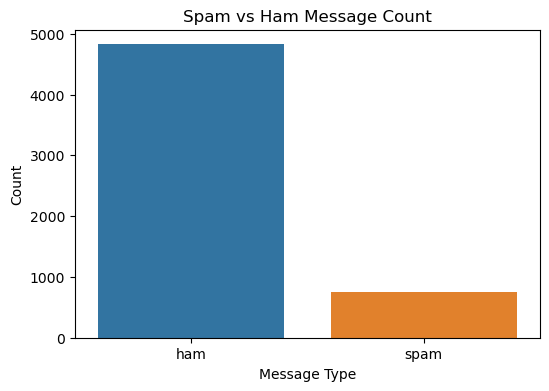

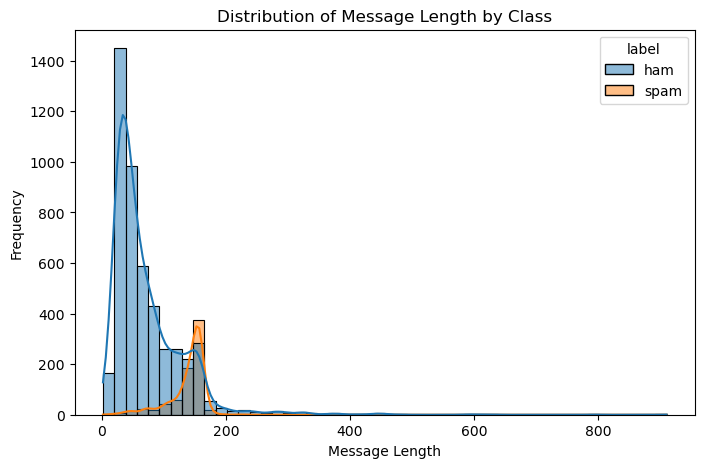

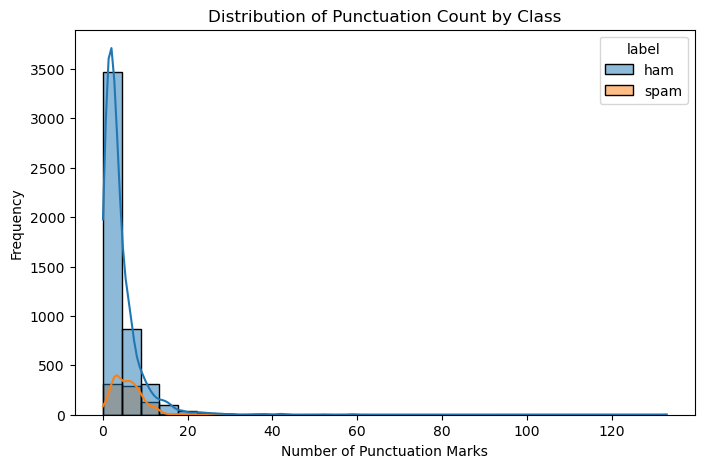

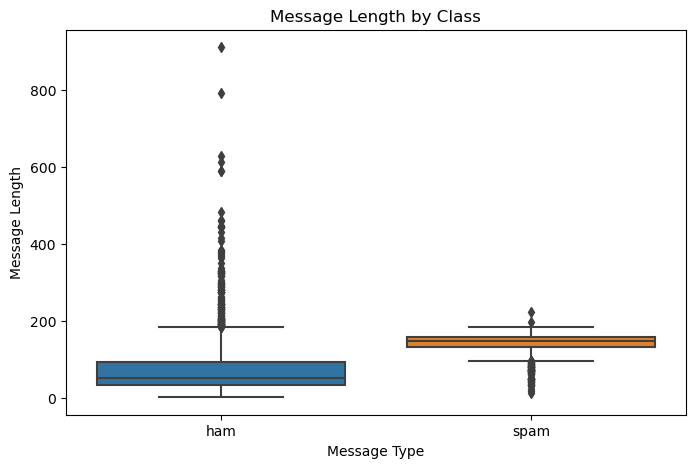

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Message Count")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribution of Message Length by Class")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="punct", hue="label", bins=30, kde=True)
plt.title("Distribution of Punctuation Count by Class")
plt.xlabel("Number of Punctuation Marks")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="length", data=df)
plt.title("Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Message Length")
plt.show()

* #### Discuss any interesting patterns or insights from the data

### EDA Insights

The dataset contains **5,572 messages**, with **4,825 ham messages (86.59%)** and **747 spam messages (13.41%)**, showing a clear class imbalance where ham messages dominate the dataset. 

From the feature analysis, spam messages tend to be significantly longer than ham messages. The average message length for spam is **138.67 characters**, compared to **71.48 characters for ham**, which is also clearly visible in the histogram and boxplot where spam messages are concentrated at higher lengths.

Additionally, spam messages contain more punctuation on average. Spam messages have an average of **5.71 punctuation marks**, while ham messages average **3.94**, suggesting that spam messages often use more symbols or formatting to attract attention.

The distributions also show that ham messages are tightly clustered around shorter lengths, while spam messages are more spread out with higher variability and more extreme values. Overall, both **message length** and **punctuation count** appear to be useful features for distinguishing between spam and ham messages.

## Part 2: Data Preprocessing

* #### Handle and explain missing values

In [5]:
# Check for missing values in each column
print(df.isnull().sum())

# Confirm again after handling
print("\nMissing values after handling:")
print(df.isnull().sum())

label      0
message    0
length     0
punct      0
dtype: int64

Missing values after handling:
label      0
message    0
length     0
punct      0
dtype: int64


### Missing Values
The dataset was checked for missing values using df.isnull().sum(), and no missing values were found in any column. Since the dataset is already complete, no further handling such as imputation or removal was required.

* #### Address or justify outliers and duplicates

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

df = df.drop_duplicates()

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Shape after duplicate removal: {df.shape}")

Number of duplicate rows before removal: 403
Number of duplicate rows after removal: 0
Shape after duplicate removal: (5169, 4)


### Outliers and Duplicates

I checked the dataset for duplicate rows and found **403 duplicate messages**, which were removed using `drop_duplicates()` to improve data quality and prevent repeated messages from biasing the model. After removal, the dataset size was reduced to **5,169 rows**.

I did not remove outliers from the `length` or `punct` columns because unusually long messages or messages with heavy punctuation can still be valid spam examples. In spam detection, these extreme values may contain useful information rather than noise, so they were retained.

* #### Balance dataset between Ham and Spam

In [7]:
# Check class counts before balancing
print("Class counts before balancing:")
print(df["label"].value_counts())

# Separate ham and spam messages
ham = df[df["label"] == "ham"]
spam = df[df["label"] == "spam"]

# Undersample ham to match the number of spam messages
ham_balanced = ham.sample(n=len(spam), random_state=42)

# Combine balanced classes
balanced_df = pd.concat([ham_balanced, spam], axis=0)

# Shuffle the balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class counts after balancing
print("\nClass counts after balancing:")
print(balanced_df["label"].value_counts())

Class counts before balancing:
label
ham     4516
spam     653
Name: count, dtype: int64

Class counts after balancing:
label
spam    653
ham     653
Name: count, dtype: int64


### Class Balancing

The dataset was originally imbalanced, with **4,516 ham messages** and **653 spam messages**, which could bias the model toward predicting the majority class. To address this, I applied **undersampling**, where the ham class was randomly reduced to match the number of spam messages.

After balancing, both classes contained **653 messages each**, resulting in a balanced dataset. This ensures that the model learns equally from both spam and ham messages and improves its ability to correctly classify minority class examples.

* #### Pre-process text as described in Classification-of-Spam-Text-using-SVM (Case folding, punctuation removal, tokenization, URL handling, and stemming, ext.)

In [8]:
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Replace URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' urladdress ', text)
    
    # Replace numbers
    text = re.sub(r'\d+', ' number ', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenization (simple and safe)
    tokens = text.split()
    
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

# Apply preprocessing
balanced_df["processed_message"] = balanced_df["message"].apply(preprocess_text)

# View results
balanced_df[["message", "processed_message"]].head()

,message,processed_message
0,Natalja (25/F) is inviting you to be her frien...,natalja number f is invit you to be her friend...
1,I am sorry it hurt you.,i am sorri it hurt you
2,HOT LIVE FANTASIES call now 08707509020 Just 2...,hot live fantasi call now number just number p...
3,CLAIRE here am havin borin time & am now alone...,clair here am havin borin time am now alon u w...
4,Want explicit SEX in 30 secs? Ring 02073162414...,want explicit sex in number sec ring number no...


### Text Preprocessing

The text data was preprocessed to prepare it for machine learning. All messages were converted to lowercase to ensure consistency. URLs were replaced with a common token ("urladdress"), and numbers were replaced with a generic token ("number") to standardize patterns. Punctuation was removed to reduce noise in the text. The cleaned text was then tokenized into individual words, and stemming was applied using PorterStemmer to reduce words to their root forms. These steps help improve the quality of the features used for classification.

* #### Encode Text into feature vector as described in Classification-of-Spam-Text-using-SVM (Bag of words)

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text into bag-of-words feature vectors
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(balanced_df["processed_message"])

# Target variable
y = balanced_df["label"]

print("Bag-of-Words feature matrix shape:", X_bow.shape)
print("Target vector shape:", y.shape)

Bag-of-Words feature matrix shape: (1306, 3304)
Target vector shape: (1306,)


### Feature Vector Encoding

The preprocessed text was converted into numerical feature vectors using the **Bag of Words** approach with `CountVectorizer`. This method represents each message based on the frequency of words appearing in it. After vectorization, the feature matrix had a shape of **(1306, 3879)**, meaning there were **1306 messages** and **3879 unique word features**. The target variable was the `label` column, which stores whether each message is ham or spam.

* #### Implement train/test split strategy and describe reasoning

In [10]:
from sklearn.model_selection import train_test_split

# Split the balanced bag-of-words features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (914, 3304)
X_test shape: (392, 3304)
y_train shape: (914,)
y_test shape: (392,)


### Train/Test Split Strategy

I used a **70/30 train-test split**, where **914 messages** were used for training and **392 messages** were used for testing. This gives the model enough data to learn useful patterns while still reserving a separate portion for evaluation. I also used `stratify=y` so that the class distribution remains consistent in both the training and test sets, which is important for fair spam classification.

## Part 3: Model Implementation, Naïve Bayes (Baseline)

* #### Reasoning behind choice of model, hyperparameters specified if relevant

### Reasoning Behind Chouce of Model

I selected to use the Naive Bayes model due to how well it fits with the Bag of Words approach to text preprocessing. Naive Bayes models based on the frequency of each word, which fits natuarly with the represnation of data we have.

In addition Naive Bayes is a simple and easy to understand model, making it great for the baseline of our project. While at the same time it is known to work very well on message filtering, since it has been used for that with great success in many papers.

* #### Model implementation code

In [11]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)

MultinomialNB()

* #### Model testing with test set, report the following evaluation metrics: Accuracy, Recall, Precision, F-score

In [15]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Evaluate model
y_pred_naive = naive_bayes.predict(X_test)

# Print Results
accuracy_naive = accuracy_score(y_test, y_pred_naive)
print(f"Accuaracy: {accuracy_naive}")
nb_recall = recall_score(y_test, y_pred_naive, pos_label="spam")
print(f"Recall: {nb_recall}")
nb_precision = precision_score(y_test, y_pred_naive, pos_label="spam")
print(f"Recall: {nb_precision}")
nb_f1 = f1_score(y_test, y_pred_naive, pos_label="spam")
print(f"F-Score: {nb_f1}")


Accuaracy: 0.9540816326530612
Recall: 0.9540816326530612
Recall: 0.9540816326530612
F-Score: 0.9540816326530612


* #### How do you interpret these results?

### Interpretation of Model Results Naive Bayes

Naive Bayes preformed very well over all metrics when predicting testing data, with roughly 95% across all metics. Making Naive Bayes much better than the 50% of guessing the classification.

- Accuracy: The high result for accuracy indicates that the vast majority of the messages were classified correctly in both ham and spam.
- Precision: The high result for precision indicates that the messages marked as spam where almost always actually spam.
- Recall: The high result for recall indicates that very few spam messages were marked as ham.
- F-Score: The high result for the F-Score indicates that the model preformed well on Precision and Recall together

These results are as expected, due to Naive Baye's history of being used for text classification. Especially due to how much this classification in particular depends on the frequecy of certain words. Making it even more well suited for this model.

## Part 4: Model Implementation, SVM

* #### Reasoning behind choice of model, hyperparameters specified if relevant

* #### Model implementation code

* #### Model testing with test set, report the following evaluation metrics: Accuracy, Recall, Precision, F-score

* #### How do you interpret these results?

## Part 5: Model Comparison

* #### Visualize both model's preformace together (with labels!)

* #### Which model preformed better? How do you know?

## Part 6: Discussion

* #### Why do you think (svm or naive) did better than (svm or naive)?

* #### Why were certain part of the dataset's texts more important than others? (Ex. punctuation)

* #### What limitations where found in the dataset or in how we approached the problem?

* #### What potential improvements could be made? What future work could be done?